In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install xgboost

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

In [3]:
dados = pd.read_csv("dados_carros.csv")

In [4]:
dados.drop(columns=['User ID'], inplace=True)

In [5]:
print(dados[['Age', 'AnnualSalary']].describe())

               Age   AnnualSalary
count  1000.000000    1000.000000
mean     40.106000   72689.000000
std      10.707073   34488.341867
min      18.000000   15000.000000
25%      32.000000   46375.000000
50%      40.000000   72000.000000
75%      48.000000   90000.000000
max      63.000000  152500.000000


In [6]:
print(dados['Gender'].value_counts())
print(dados['Purchased'].value_counts())

Gender
Female    516
Male      484
Name: count, dtype: int64
Purchased
0    598
1    402
Name: count, dtype: int64


In [7]:
dados = pd.get_dummies(dados,
                       columns=['Gender'],
                       drop_first=True,
                       dtype='int')

In [8]:
X = dados.drop(columns=['Purchased'])
y = dados['Purchased']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

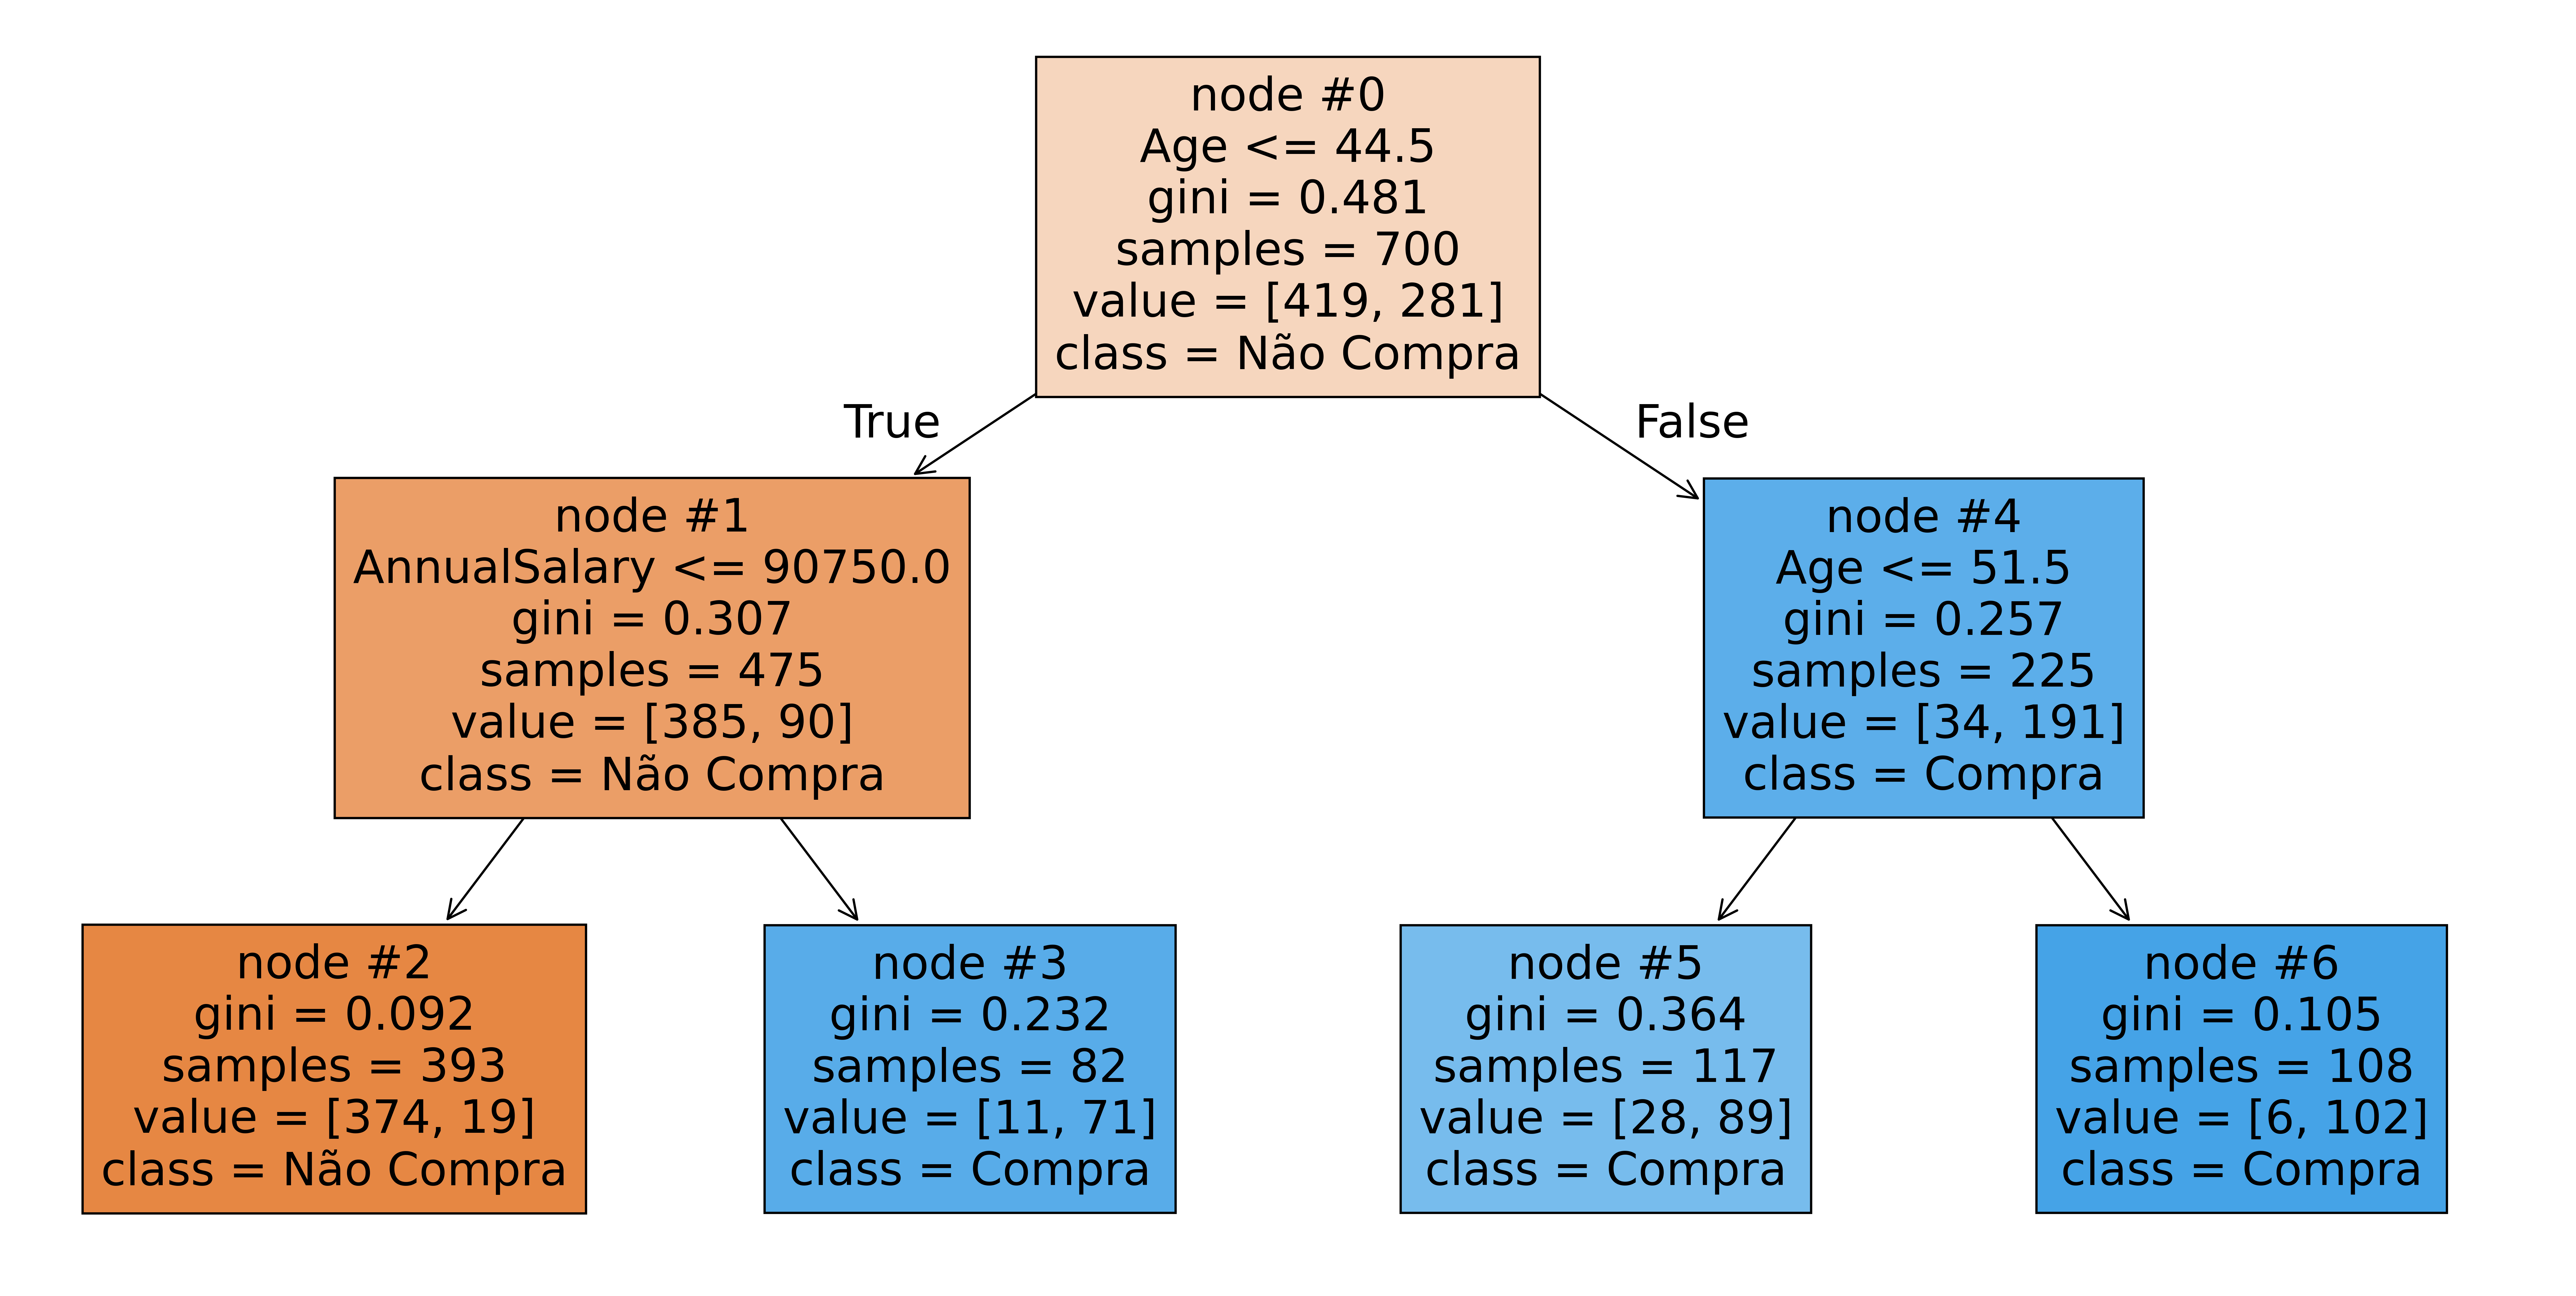

In [11]:
# Gerando a árvore de decisão

tree_clf = DecisionTreeClassifier(criterion='gini',
                                  splitter='best',
                                  max_depth=2,
                                  min_samples_split=2,
                                  min_samples_leaf=1,
                                  min_weight_fraction_leaf=0.0,
                                  max_features=None,
                                  random_state=100,
                                  max_leaf_nodes=None,
                                  min_impurity_decrease=0.0,
                                  ccp_alpha=0.0)
tree_clf.fit(X_train, y_train)

# Plotando a árvore

plt.figure(figsize=(20,10), dpi=600)
plot_tree(tree_clf,
          feature_names=X.columns.tolist(),
          class_names=['Não Compra', 'Compra'],
          proportion=False,
          filled=True,
          node_ids=True)
plt.show()

In [12]:
# Analisando os resultados dos splits

tree_split = pd.DataFrame(tree_clf.cost_complexity_pruning_path(X_train, y_train))
tree_split.sort_index(ascending=False, inplace=True)

print(tree_split)

   ccp_alphas  impurities
3    0.189683    0.480567
2    0.129547    0.290885
1    0.005418    0.161337
0    0.000000    0.155919


In [13]:
# Importância das variáveis preditoras

tree_features = pd.DataFrame({'features':X.columns.tolist(),
                              'importance':tree_clf.feature_importances_})

print(tree_features)

       features  importance
0           Age    0.600961
1  AnnualSalary    0.399039
2   Gender_Male    0.000000


In [14]:
# Obtendo os valores preditos pela árvore

# Predict na base de treinamento
tree_pred_train_class = tree_clf.predict(X_train)
tree_pred_train_prob = tree_clf.predict_proba(X_train)

# Predict na base de testes
tree_pred_test_class = tree_clf.predict(X_test)
tree_pred_test_prob = tree_clf.predict_proba(X_test)


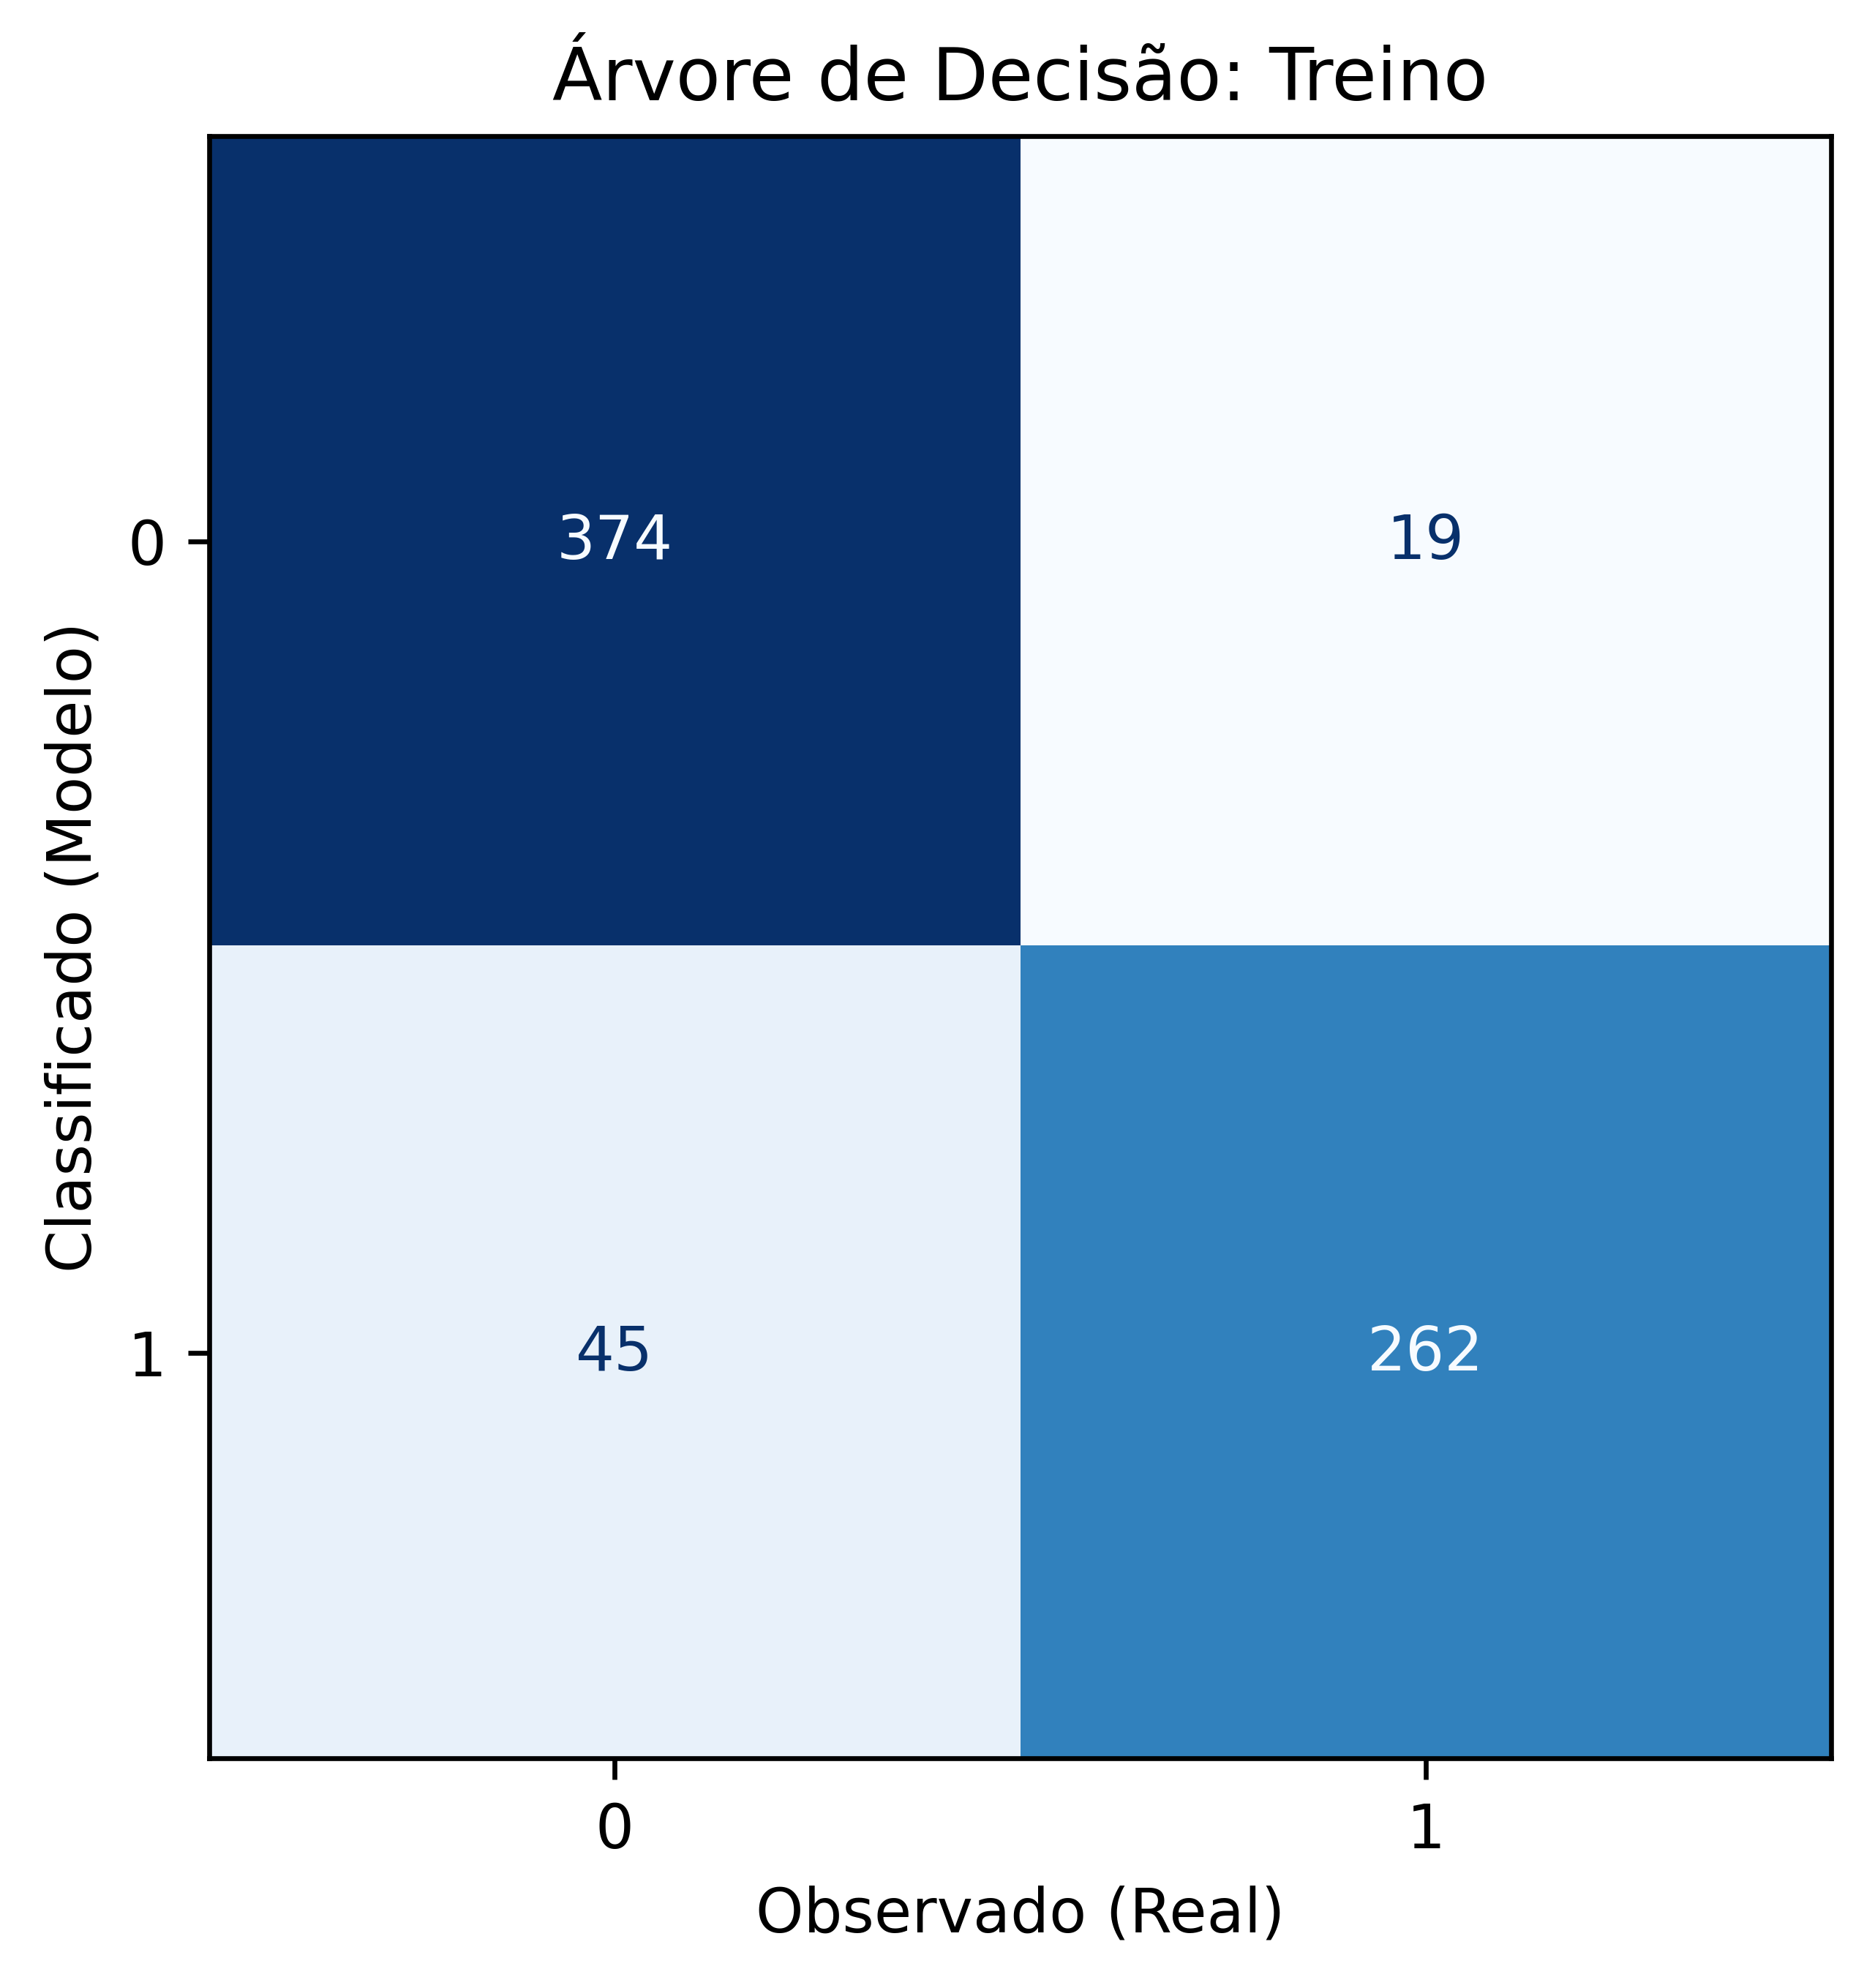

Avaliação da Árvore (Base de Treino)
Acurácia: 90.9%
Sensibilidade: 93.2%
Especificidade: 89.3%
Precision: 85.3%


In [15]:
# Matriz de confusão (base de treino)

tree_cm_train = confusion_matrix(tree_pred_train_class, y_train)
cm_train_disp_tree = ConfusionMatrixDisplay(tree_cm_train)

plt.rcParams['figure.dpi'] = 600
cm_train_disp_tree.plot(colorbar=False, cmap='Blues')
plt.title('Árvore de Decisão: Treino')
plt.xlabel('Observado (Real)')
plt.ylabel('Classificado (Modelo)')
plt.show()

acc_tree_train = accuracy_score(y_train, tree_pred_train_class)
sens_tree_train = recall_score(y_train, tree_pred_train_class, pos_label=1)
espec_tree_train = recall_score(y_train, tree_pred_train_class, pos_label=0)
prec_tree_train = precision_score(y_train, tree_pred_train_class)

print("Avaliação da Árvore (Base de Treino)")
print(f"Acurácia: {acc_tree_train:.1%}")
print(f"Sensibilidade: {sens_tree_train:.1%}")
print(f"Especificidade: {espec_tree_train:.1%}")
print(f"Precision: {prec_tree_train:.1%}")


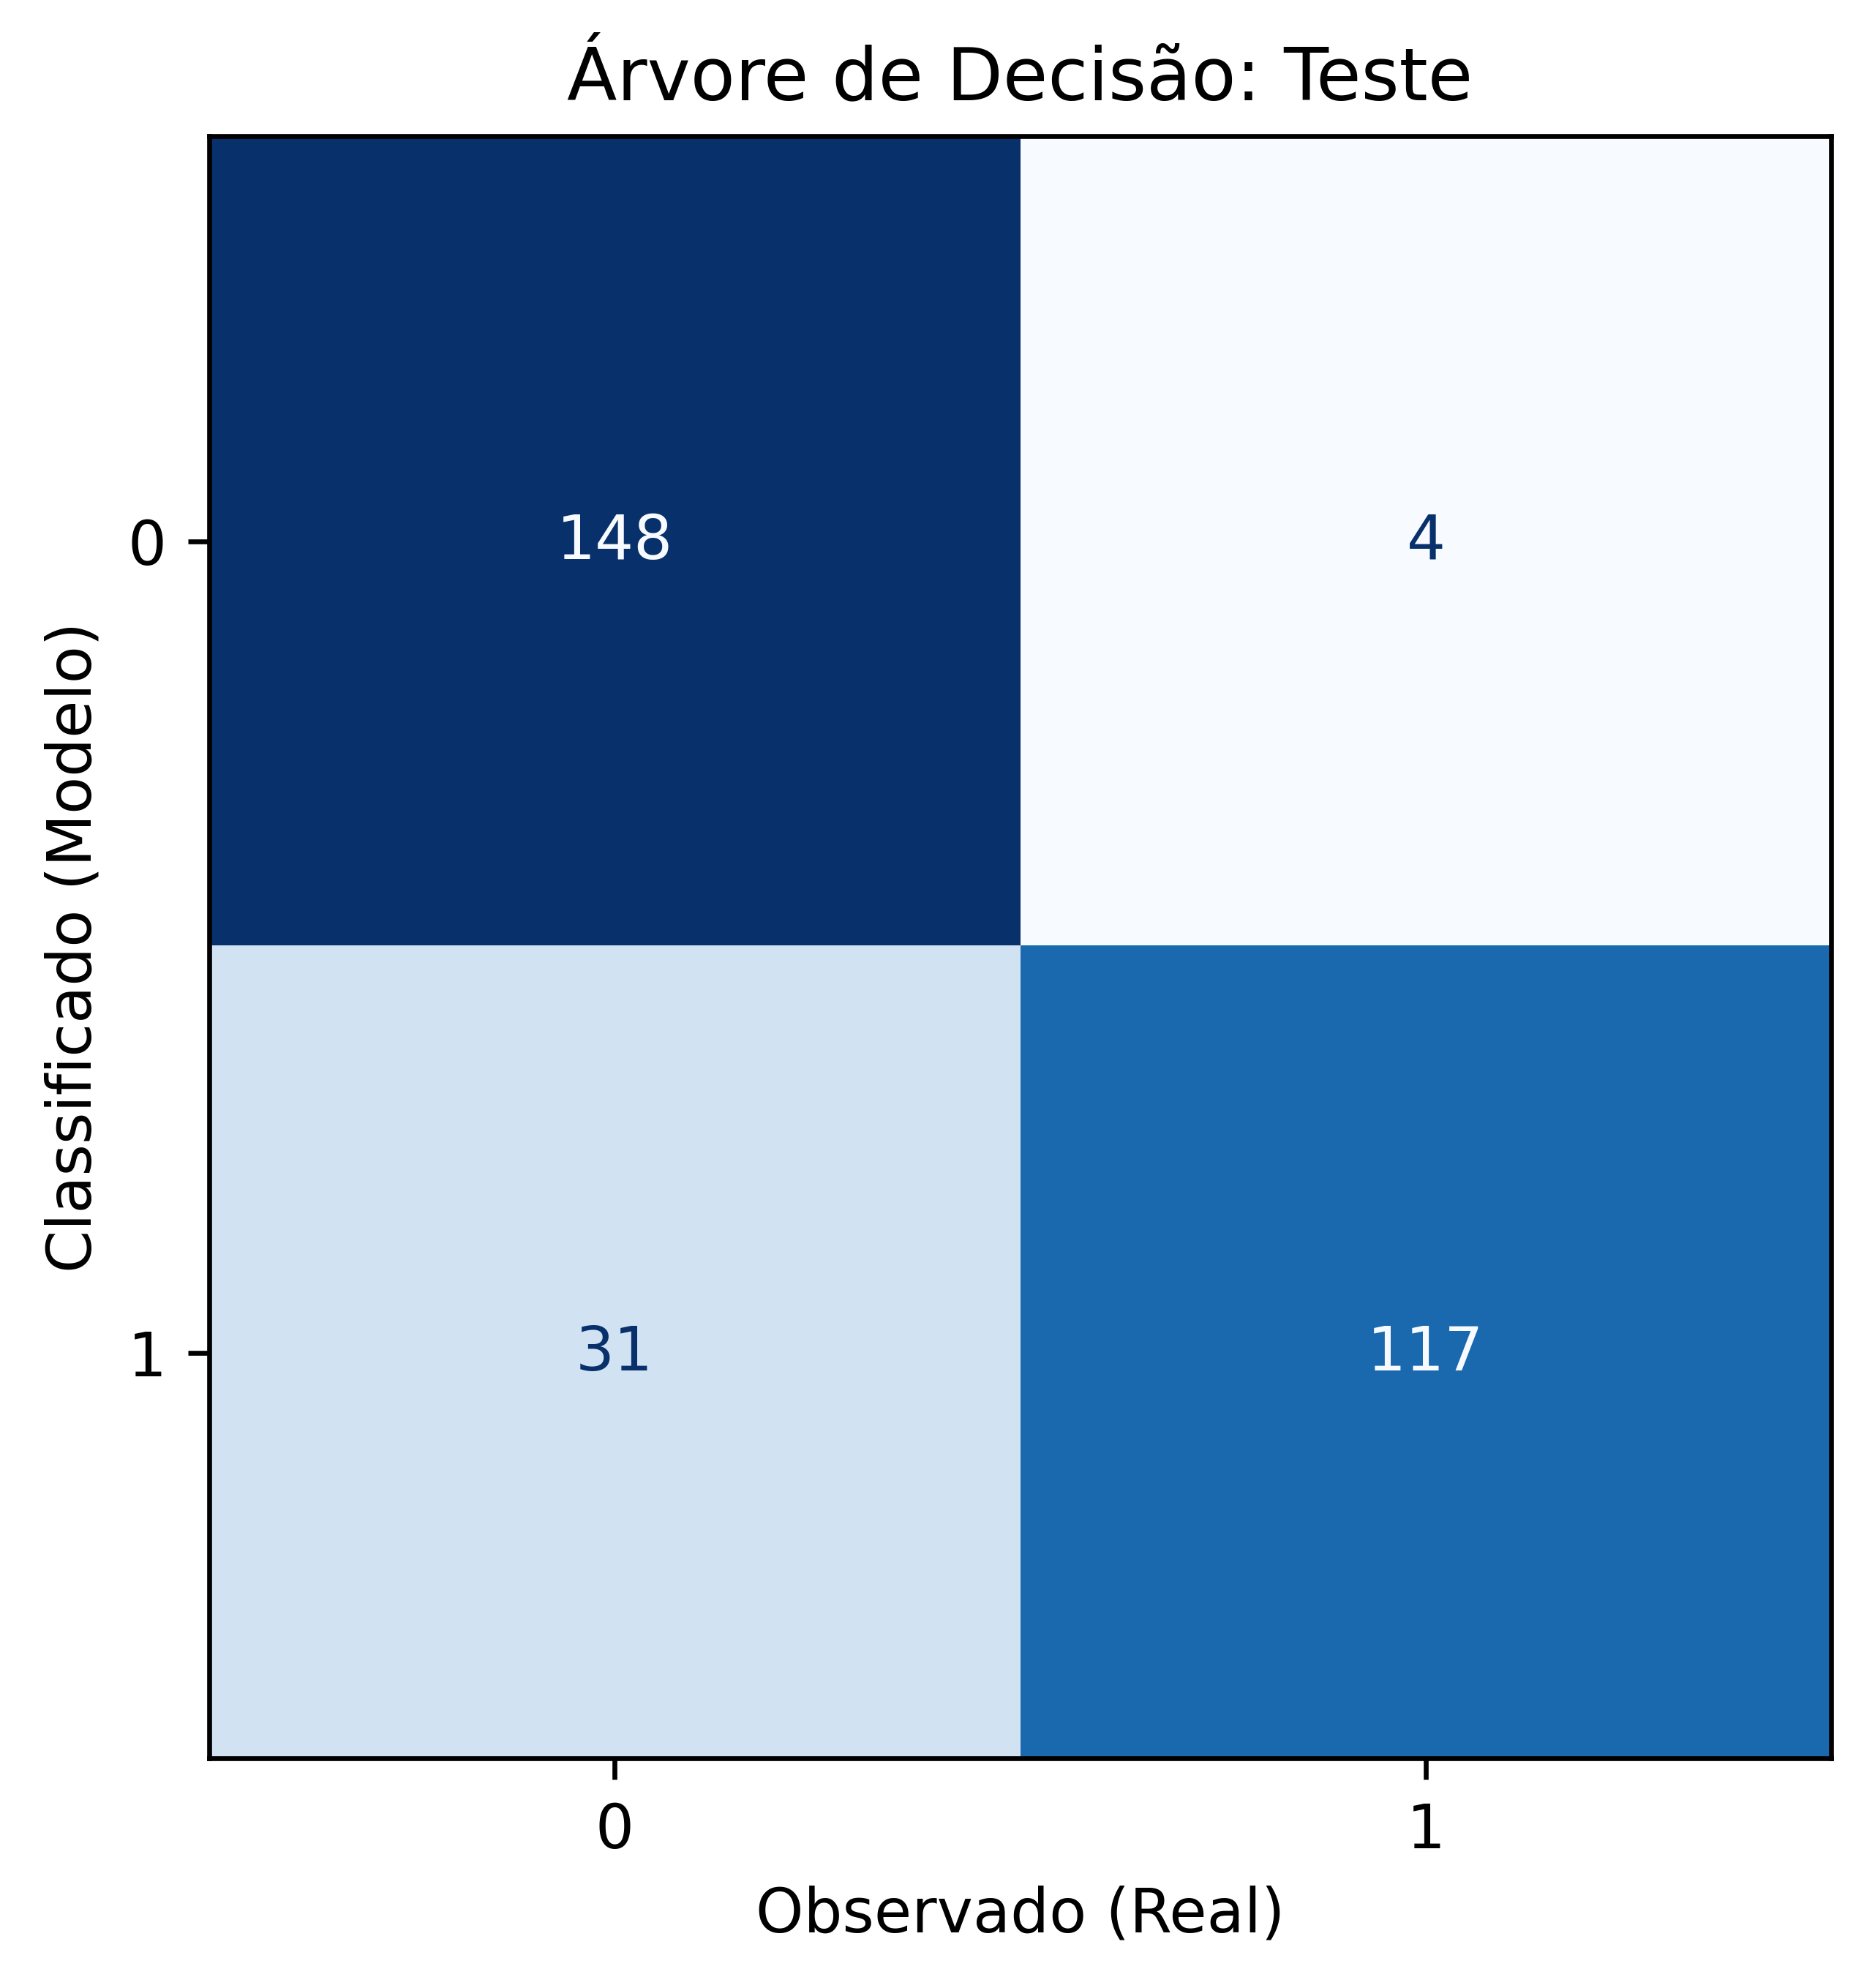

Avaliação da Árvore (Base de Teste)
Acurácia: 88.3%
Sensibilidade: 96.7%
Especificidade: 82.7%
Precision: 79.1%


In [16]:
# Matriz de confusão (base de teste)

tree_cm_test = confusion_matrix(tree_pred_test_class, y_test)
cm_test_disp_tree = ConfusionMatrixDisplay(tree_cm_test)

plt.rcParams['figure.dpi'] = 600
cm_test_disp_tree.plot(colorbar=False, cmap='Blues')
plt.title('Árvore de Decisão: Teste')
plt.xlabel('Observado (Real)')
plt.ylabel('Classificado (Modelo)')
plt.show()

acc_tree_test = accuracy_score(y_test, tree_pred_test_class)
sens_tree_test = recall_score(y_test, tree_pred_test_class, pos_label=1)
espec_tree_test = recall_score(y_test, tree_pred_test_class, pos_label=0)
prec_tree_test = precision_score(y_test, tree_pred_test_class)

print("Avaliação da Árvore (Base de Teste)")
print(f"Acurácia: {acc_tree_test:.1%}")
print(f"Sensibilidade: {sens_tree_test:.1%}")
print(f"Especificidade: {espec_tree_test:.1%}")
print(f"Precision: {prec_tree_test:.1%}")


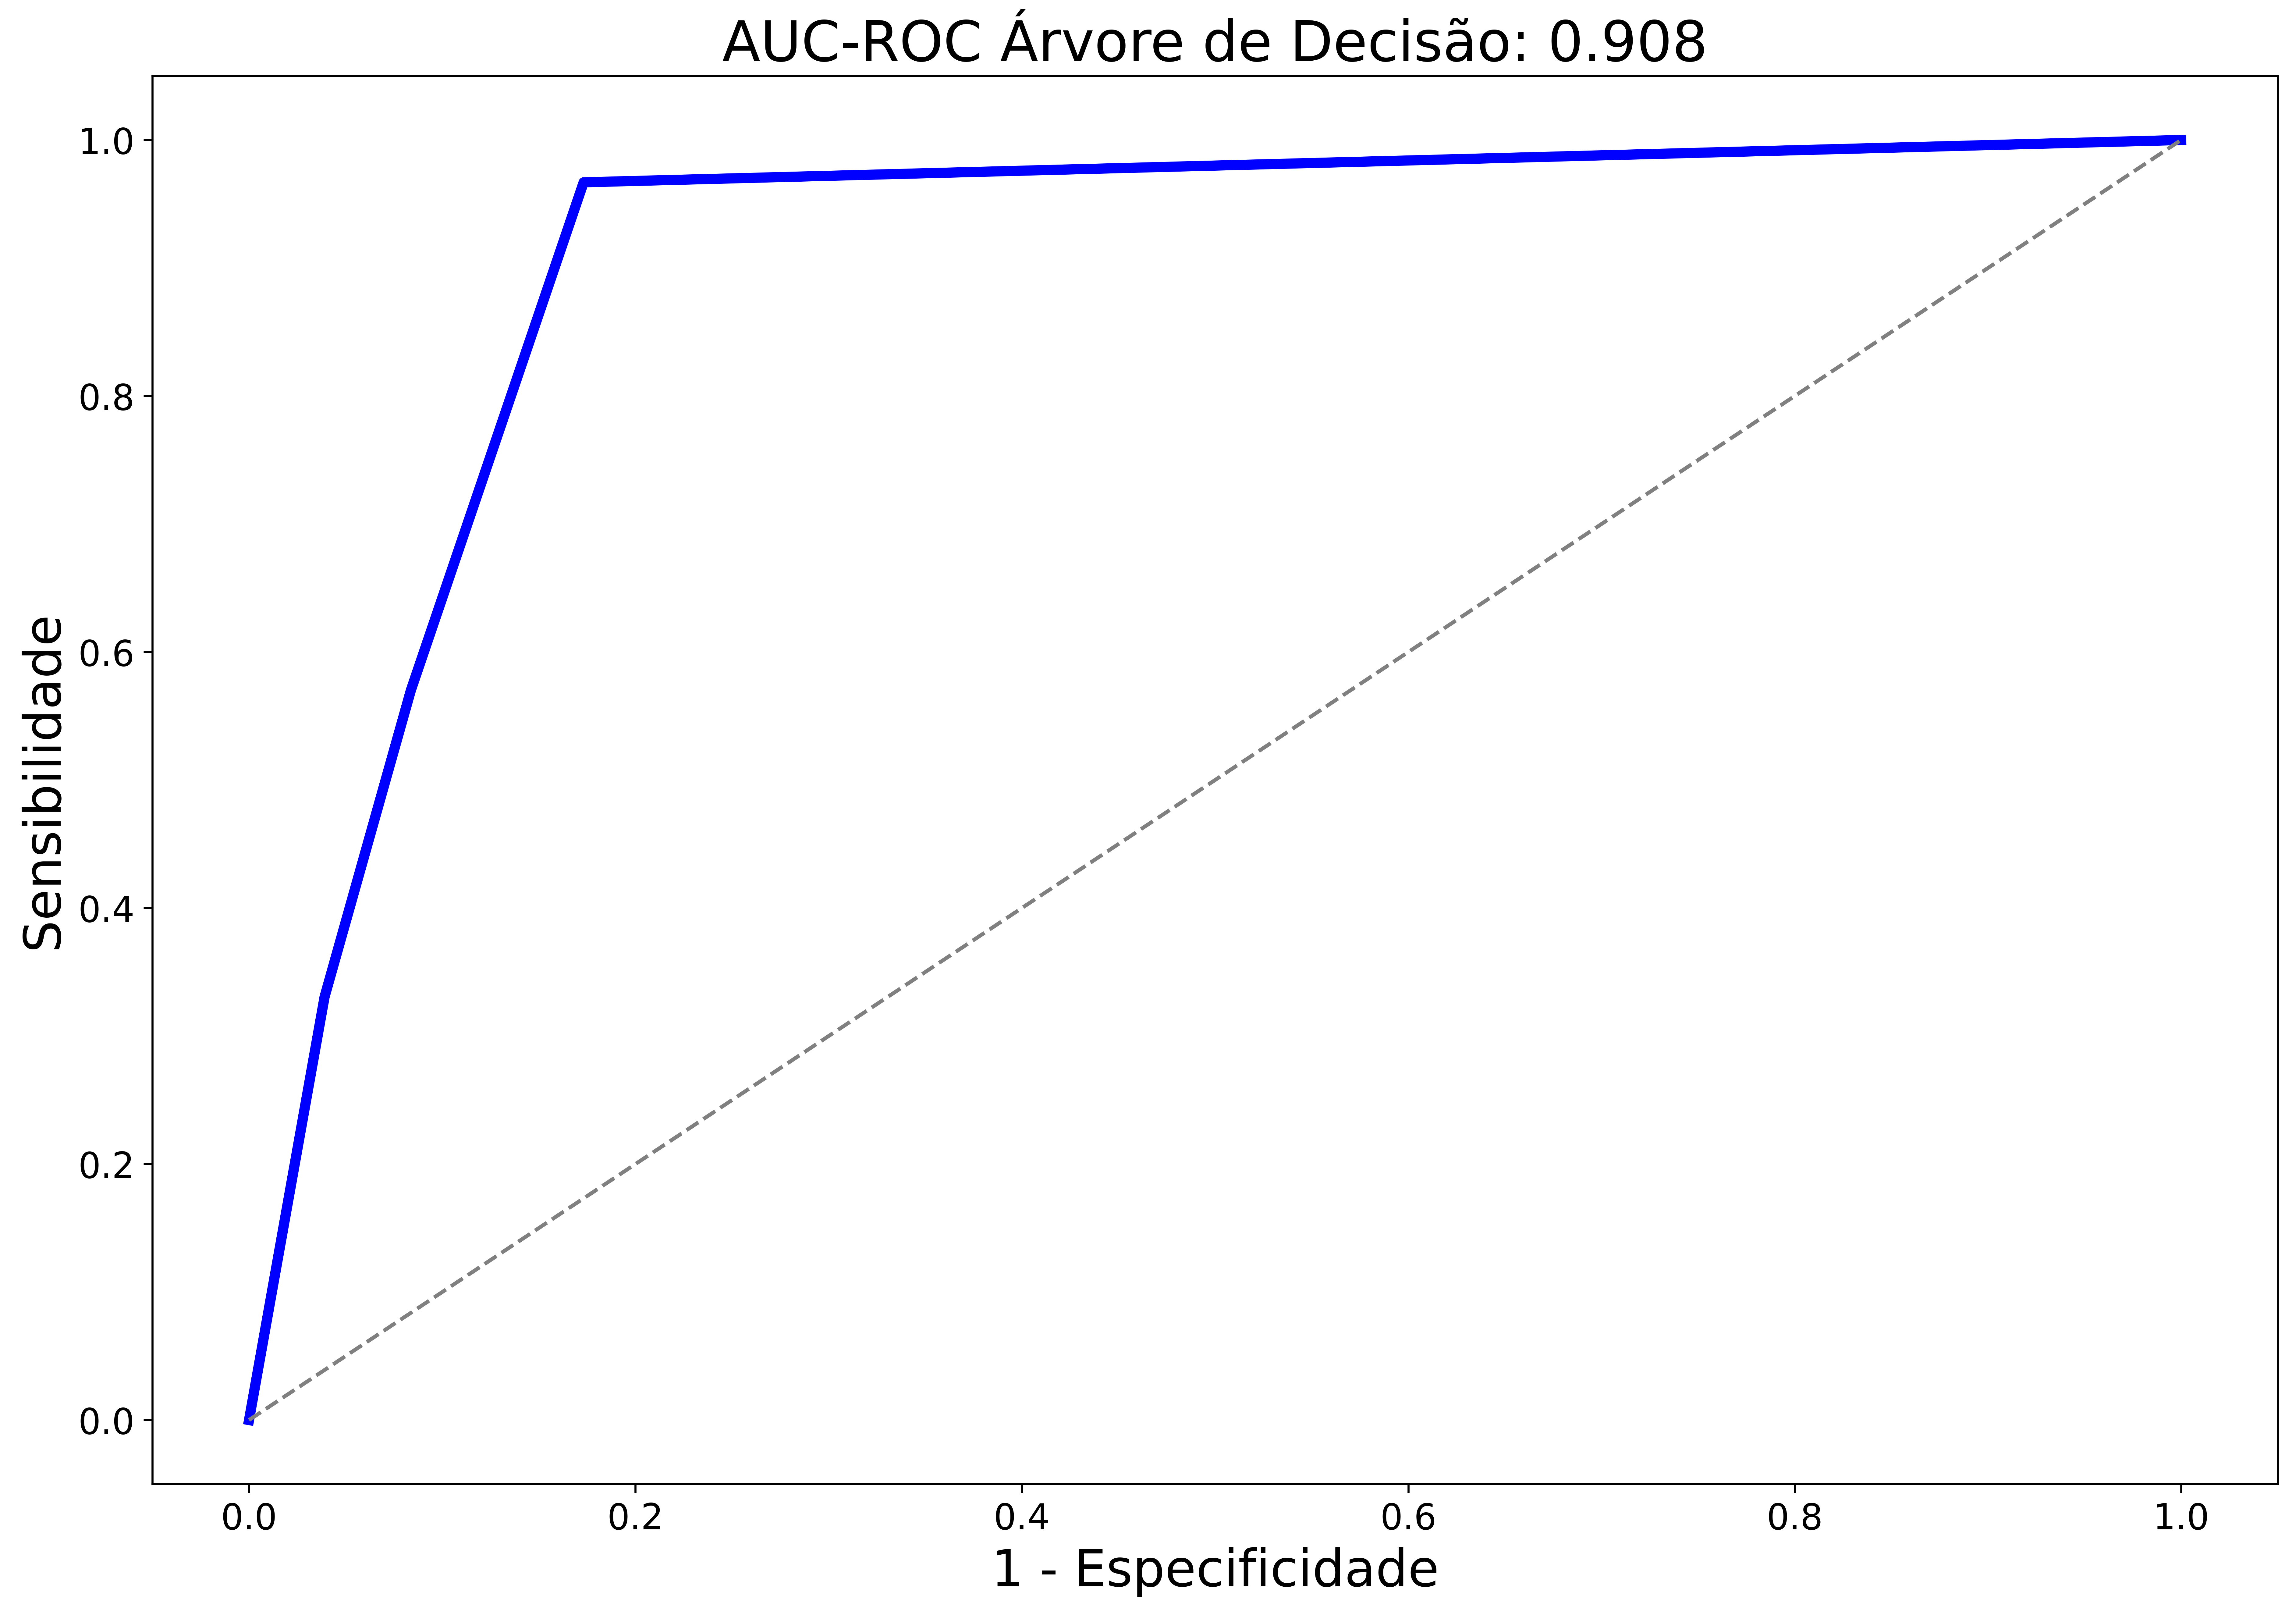

In [17]:
# Curva ROC (base de teste)

# Parametrizando a função da curva ROC (real vs. previsto)
fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, tree_pred_test_prob[:,1])
roc_auc_tree = auc(fpr_tree, tpr_tree)

# Plotando a curva ROC
plt.figure(figsize=(15,10), dpi=600)
plt.plot(fpr_tree, tpr_tree, color='blue', linewidth=4)
plt.plot(fpr_tree, fpr_tree, color='gray', linestyle='dashed')
plt.title('AUC-ROC Árvore de Decisão: %g' % round(roc_auc_tree, 3), fontsize=22)
plt.xlabel('1 - Especificidade', fontsize=20)
plt.ylabel('Sensibilidade', fontsize=20)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.show()